<a href="https://colab.research.google.com/github/olit12321/PMN-26L/blob/main/Task_3/Task_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
torch.manual_seed(42)
np.random.seed(42)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Pracujemy na urządzeniu: {device}")

Pracujemy na urządzeniu: cpu



#Ustawienie ziarna losowości dla powtarzalności wyników

In [4]:

!mkdir -p ./data

!wget -c https://web.archive.org/web/20230608035118/https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz -O ./data/cifar-10-python.tar.gz



--2026-05-03 13:29:50--  https://web.archive.org/web/20230608035118/https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz
Resolving web.archive.org (web.archive.org)... 207.241.237.3
Connecting to web.archive.org (web.archive.org)|207.241.237.3|:443... connected.
HTTP request sent, awaiting response... 302 FOUND
Location: https://web.archive.org/web/20230711193520/http://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz [following]
--2026-05-03 13:29:51--  https://web.archive.org/web/20230711193520/http://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz
Reusing existing connection to web.archive.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 170498071 (163M) [application/x-gzip]
Saving to: ‘./data/cifar-10-python.tar.gz’

./data/cifar-10-pyt 100%[===================>] 162.60M  44.3MB/s    in 4.0s    

2026-05-03 13:29:59 (40.2 MB/s) - ‘./data/cifar-10-python.tar.gz’ saved [170498071/170498071]

Pobieranie zakończone! Teraz PyTorch powinien widzieć plik lokalnie.


#pobieranie zbioru lokalnie, poniewaz strona miala awarie

In [5]:

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])


full_train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


Dane załadowane poprawnie!


# Transformacje obrazków (zamiana na tensor i normalizacja kolorów RGB)
# Podział na zbiór treningowy i walidacyjny (80% / 20%)
# Tworzenie DataLoaderów (na razie z domyślnym batch_size=64, zmienimy to w eksperymentach)

## 2. Eksploracyjna Analiza Danych (EDA)
Zanim przejdziemy do budowy sieci, musimy zrozumieć, z jakimi danymi pracujemy. Zbiór CIFAR-10 to klasyczny problem wizji komputerowej.
Poniżej sprawdzamy:
1. **Statystyki zbioru:** Wymiary pojedynczego obrazka oraz zakres wartości pikseli po nałożeniu naszej normalizacji.
2. **Przykładowe obrazy:** Wizualizacja małej próbki danych, aby upewnić się, że ładują się poprawnie i mają przypisane właściwe etykiety.
3. **Rozkład klas:** Sprawdzenie, czy nasz podzbiór treningowy jest zbalansowany (tzn. czy sieć ma szansę uczyć się każdej klasy po równo).

--- STATYSTYKI ZBIORU DANYCH ---
Wymiary pojedynczego wejścia: torch.Size([3, 32, 32]) -> (Liczba kanałów RGB, Wysokość, Szerokość)
Zakres wartości pikseli (po normalizacji): min = -1.9895, max = 2.1265


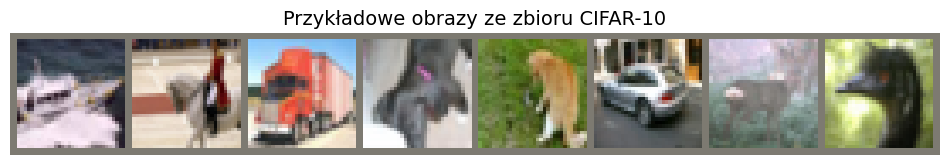

Prawdziwe etykiety dla powyższych obrazów:
ship  | horse | truck | dog   | cat   | car   | deer  | bird 

Obliczanie rozkładu klas w zbiorze treningowym (to może zająć kilka sekund)...


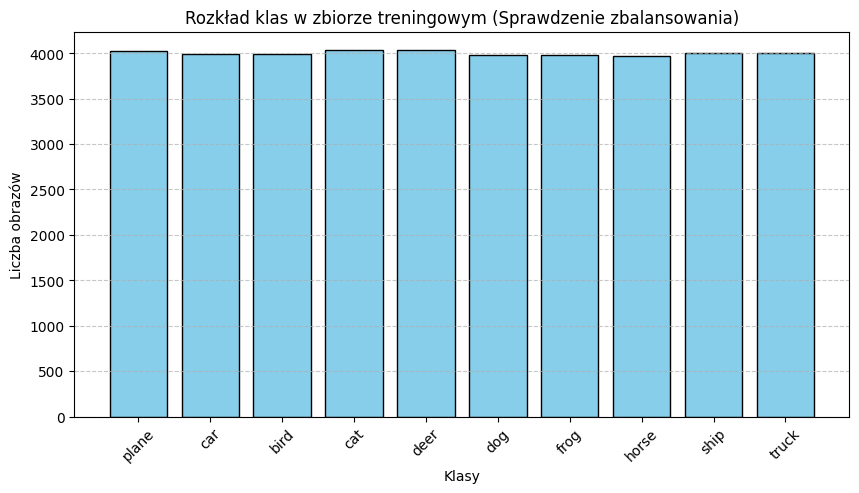

In [15]:
# 1. Statystyki zbioru (wymiary i wartości pikseli)
dataiter = iter(train_loader)
images, labels = next(dataiter)

print("--- STATYSTYKI ZBIORU DANYCH ---")
print(f"Wymiary pojedynczego wejścia: {images[0].shape} -> (Liczba kanałów RGB, Wysokość, Szerokość)")
print(f"Zakres wartości pikseli (po normalizacji): min = {images.min().item():.4f}, max = {images.max().item():.4f}")

# 2. Przykładowe obrazy (Wizualizacja)
def imshow_eda(img):
    # Dokładna denormalizacja, aby przywrócić oryginalne kolory do wyświetlenia
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2470, 0.2435, 0.2616])
    npimg = img.numpy()
    npimg = np.transpose(npimg, (1, 2, 0)) # Zmiana osi dla Matplotlib
    npimg = std * npimg + mean
    npimg = np.clip(npimg, 0, 1)
    plt.imshow(npimg)
    plt.axis('off')

plt.figure(figsize=(12, 4))
plt.title("Przykładowe obrazy ze zbioru CIFAR-10", fontsize=14)
plt.axis('off')
# Pobieramy 8 pierwszych obrazków z paczki
imshow_eda(torchvision.utils.make_grid(images[:8]))
plt.show()

print("Prawdziwe etykiety dla powyższych obrazów:")
print(' | '.join(f'{classes[labels[j]]:5s}' for j in range(8)))

# 3. Rozkład klas w zbiorze treningowym
print("\nObliczanie rozkładu klas w zbiorze treningowym (to może zająć kilka sekund)...")
class_counts = {classname: 0 for classname in classes}

# Przechodzimy przez zbiór treningowy, aby zliczyć wystąpienia
for _, label in train_dataset:
    class_counts[classes[label]] += 1

plt.figure(figsize=(10, 5))
plt.bar(class_counts.keys(), class_counts.values(), color='skyblue', edgecolor='black')
plt.title('Rozkład klas w zbiorze treningowym (Sprawdzenie zbalansowania)')
plt.xlabel('Klasy')
plt.ylabel('Liczba obrazów')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [6]:
class FlexCNN(nn.Module):
    def __init__(self, kernel_size=3, pool_type='MaxPool'):
        super(FlexCNN, self).__init__()

        pad = kernel_size // 2


        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=kernel_size, padding=pad)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=kernel_size, padding=pad)

        self.relu = nn.ReLU()

        if pool_type == 'MaxPool':
            self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        elif pool_type == 'AvgPool':
            self.pool = nn.AvgPool2d(kernel_size=2, stride=2)
        else:
            self.pool = nn.Identity()

        spatial_dim = 8 if pool_type in ['MaxPool', 'AvgPool'] else 32


        self.fc1 = nn.Linear(64 * spatial_dim * spatial_dim, 512)
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)

        x = torch.flatten(x, 1)

        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

# Dwie warstwy konwolucyjne (zgodnie z poleceniem)
# Rodzaj poolingu (potrzebne do eksperymentów)
# Warstwy w pełni połączone (MLP na końcu sieci CNN)
# Spłaszczenie obrazu przed podaniem do warstw FC

In [7]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total


        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss /= len(val_loader)
        val_acc = correct / total

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    return history


* **Faza treningu:** Przechodzi przez wszystkie paczki danych treningowych (batche), oblicza błąd modelu (Loss) na podstawie jego przewidywań i aktualizuje wagi sieci z wykorzystaniem algorytmu propagacji wstecznej (Backpropagation).
* **Faza walidacji:** Po każdej epoce treningowej model jest sprawdzany na zbiorze walidacyjnym (tutaj wagi nie są już aktualizowane). Pozwala to na bieżąco monitorować, czy model uczy się ogólnych cech, czy tylko "zapamiętuje" dane (tzw. przeuczenie / overfitting).
* **Zapis historii:** Funkcja na bieżąco zbiera wartości funkcji straty oraz dokładności (Accuracy) dla obu zbiorów, a na koniec zwraca je w postaci wygodnego słownika, który posłuży nam później do wygenerowania wykresów.


## 5. Moduł Wizualizacji Eksperymentów
Zgodnie z dobrymi praktykami DRY (Don't Repeat Yourself), tworzymy dedykowaną funkcję `plot_experiment_results`. Przyjmie ona słownik z historiami uczenia (zwracanymi przez naszą funkcję

`train_model`) i wygeneruje przejrzyste wykresy porównawcze dla funkcji straty (Loss) oraz dokładności (Accuracy) na jednym obrazku.

In [8]:
def plot_experiment_results(results_dict, experiment_name):
    """
    Zaktualizowana funkcja: Rysuje osobne podwykresy dla każdego wariantu hiperparametru,
    co znacznie poprawia czytelność.
    """
    num_experiments = len(results_dict)
    # Tworzymy siatkę: 2 wiersze (Loss, Acc), N kolumn (dla każdego modelu)
    fig, axes = plt.subplots(2, num_experiments, figsize=(6 * num_experiments, 10))
    fig.suptitle(f'Eksperyment: {experiment_name}', fontsize=16, fontweight='bold', y=1.02)

    for i, (param_val, history) in enumerate(results_dict.items()):
        epochs = range(1, len(history['train_loss']) + 1)

        # GÓRNY WIERSZ: Wartość funkcji straty (Loss)
        ax_loss = axes[0, i] if num_experiments > 1 else axes[0]
        ax_loss.plot(epochs, history['train_loss'], 'o--', label='Train Loss', color='gray', alpha=0.7)
        ax_loss.plot(epochs, history['val_loss'], 'o-', label='Val Loss', color='red', linewidth=2)
        ax_loss.set_title(f'Model: {param_val}\n(Loss)')
        ax_loss.set_xlabel('Epoka')
        ax_loss.set_ylabel('Loss')
        ax_loss.grid(True, linestyle='--', alpha=0.5)
        ax_loss.legend()

        # DOLNY WIERSZ: Dokładność (Accuracy)
        ax_acc = axes[1, i] if num_experiments > 1 else axes[1]
        ax_acc.plot(epochs, history['train_acc'], 'o--', label='Train Acc', color='gray', alpha=0.7)
        ax_acc.plot(epochs, history['val_acc'], 'o-', label='Val Acc', color='green', linewidth=2)
        ax_acc.set_title(f'Model: {param_val}\n(Accuracy)')
        ax_acc.set_xlabel('Epoka')
        ax_acc.set_ylabel('Accuracy')
        ax_acc.grid(True, linestyle='--', alpha=0.5)
        ax_acc.legend()

    plt.tight_layout()
    plt.show()

 # Tworzymy siatkę: 2 wiersze (Loss, Acc), N kolumn (dla każdego modelu)
  # GÓRNY WIERSZ: Wartość funkcji straty (Loss)
   # DOLNY WIERSZ: Dokładność (Accuracy)

## 6. Seria Eksperymentów (Sieć CNN)
### Eksperyment 1: Wpływ rozmiaru filtra (Kernel Size)
W tym eksperymencie sprawdzimy, jak rozmiar filtru konwolucyjnego (3x3, 5x5, 7x7) wpływa na zdolność sieci do ekstrakcji cech z obrazów CIFAR-10.
Zostawiamy stały algorytm optymalizacji (Adam), stały `Learning Rate` (0.001) oraz domyślny `Batch Size` (64). Zmieniamy wyłącznie architekturę przekazując parametr `kernel_size` do naszej klasy `FlexCNN`. Wykonamy po 5 epok dla każdego modelu, aby zobaczyć wstępny trend uczenia.


Rozpoczynam trening dla Kernel Size = 3x3
Epoch 1/5 | Train Loss: 1.3066 Acc: 0.5323 | Val Loss: 1.0504 Acc: 0.6291
Epoch 2/5 | Train Loss: 0.9154 Acc: 0.6783 | Val Loss: 0.8714 Acc: 0.6985
Epoch 3/5 | Train Loss: 0.7245 Acc: 0.7450 | Val Loss: 0.8425 Acc: 0.7132
Epoch 4/5 | Train Loss: 0.5500 Acc: 0.8063 | Val Loss: 0.8444 Acc: 0.7152
Epoch 5/5 | Train Loss: 0.3827 Acc: 0.8679 | Val Loss: 0.9562 Acc: 0.7038

Rozpoczynam trening dla Kernel Size = 5x5
Epoch 1/5 | Train Loss: 1.3881 Acc: 0.5016 | Val Loss: 1.1600 Acc: 0.5884
Epoch 2/5 | Train Loss: 0.9983 Acc: 0.6484 | Val Loss: 0.9558 Acc: 0.6672
Epoch 3/5 | Train Loss: 0.8022 Acc: 0.7182 | Val Loss: 0.9039 Acc: 0.6834
Epoch 4/5 | Train Loss: 0.6366 Acc: 0.7779 | Val Loss: 0.8671 Acc: 0.7073
Epoch 5/5 | Train Loss: 0.4825 Acc: 0.8298 | Val Loss: 0.9147 Acc: 0.7079

Rozpoczynam trening dla Kernel Size = 7x7
Epoch 1/5 | Train Loss: 1.5306 Acc: 0.4444 | Val Loss: 1.2524 Acc: 0.5606
Epoch 2/5 | Train Loss: 1.1603 Acc: 0.5892 | Val Loss: 1.

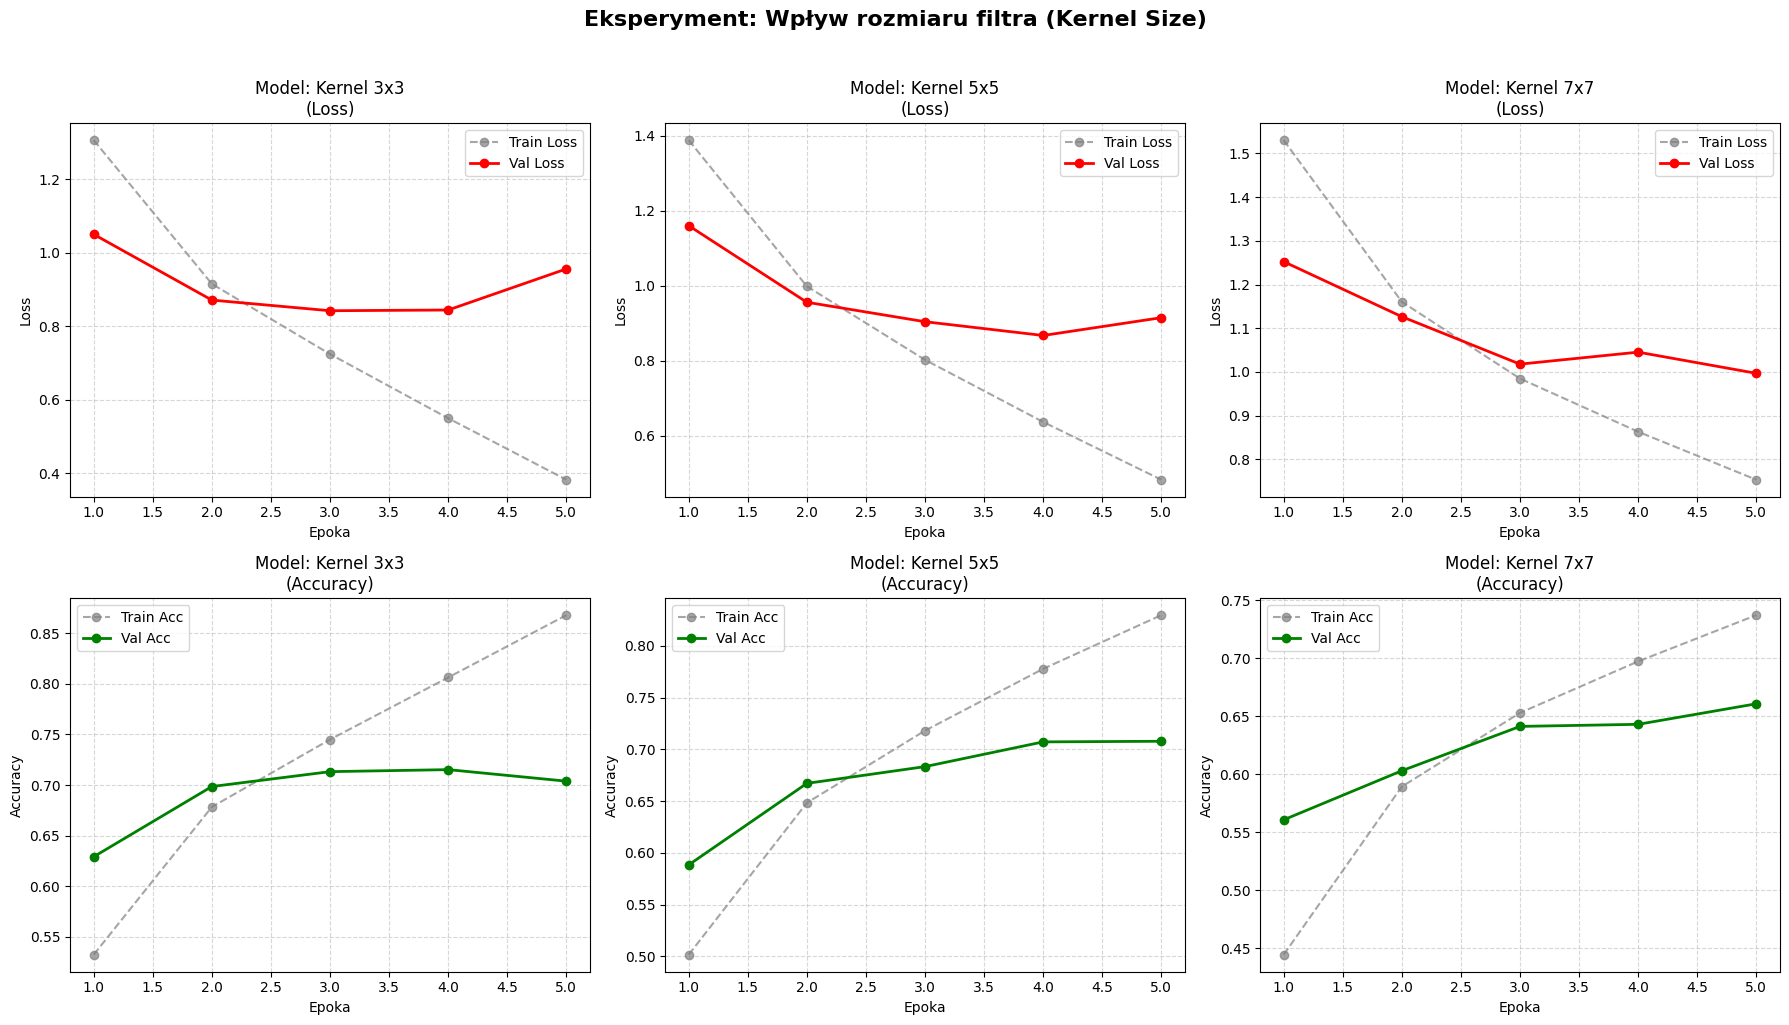

In [9]:
# Słownik, w którym zapiszemy wyniki każdego z 3 modeli
kernel_results = {}
kernel_sizes = [3, 5, 7]
num_epochs = 5 # Ustawiamy 5 epok. Trening chwilę potrwa.

# Funkcja straty (Loss) dla klasyfikacji wieloklasowej
criterion = nn.CrossEntropyLoss()

for ks in kernel_sizes:
    print(f"\n{'='*40}")
    print(f"Rozpoczynam trening dla Kernel Size = {ks}x{ks}")
    print(f"{'='*40}")

    # 1. Inicjalizacja modelu z konkretnym rozmiarem filtra
    model = FlexCNN(kernel_size=ks, pool_type='MaxPool').to(device)

    # 2. Definicja optymalizatora dla tego modelu
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # 3. Trening (wywołujemy naszą funkcję)
    history = train_model(model, train_loader, val_loader, criterion, optimizer, epochs=num_epochs)

    # 4. Zapisanie wyników
    kernel_results[f'Kernel {ks}x{ks}'] = history

# Wywołanie naszej dedykowanej funkcji rysującej wykresy!
plot_experiment_results(kernel_results, "Wpływ rozmiaru filtra (Kernel Size)")

**Wnioski z eksperymentu (Kernel Size):**
Na podstawie wykresów uczenia wyraźnie widać zjawisko przeuczenia (overfitting). Dokładność na zbiorze treningowym (`Train Acc`) dla wszystkich filtrów systematycznie rośnie, osiągając wysokie wartości, podczas gdy błąd (`Train Loss`) szybko maleje. Z kolei na zbiorze walidacyjnym błąd (`Val Loss`) po 3. epoce zaczyna niebezpiecznie rosnąć.
Porównując rozmiary filtrów, najlepszy stosunek dopasowania do możliwości generalizacji wykazał model z filtrem `3x3`. Uzyskał on ostatecznie najwyższe `Val Acc` (powyżej 70%) oraz stosunkowo najmniej rósł w nim błąd walidacyjny w końcowej fazie treningu w porównaniu do większych filtrów (5x5 i 7x7). Widać tu, że dla tak małych obrazów (32x32) małe filtry konwolucyjne skuteczniej budują odpowiednie reprezentacje cech.

### Eksperyment 2: Wpływ warstwy zrzutu (Pooling)
W tym eksperymencie sprawdzimy, jak rodzaj użytej warstwy `Pooling` wpływa na jakość i szybkość uczenia sieci. Ustalimy rozmiar filtra na 3x3 (ponieważ wypadł najlepiej w poprzednim eksperymencie).

Sprawdzimy trzy warianty:
1. **MaxPool** - wybiera najsilniejszą cechę (największą wartość) z danego obszaru. Zazwyczaj najlepiej sprawdza się w wyciąganiu ostrych krawędzi.
2. **AvgPool** - uśrednia wartości. Działa bardziej "wygładzająco".
3. **Brak poolingu (None)** - przekazujemy pełną rozdzielczość obrazu aż do warstw w pełni połączonych (MLP), co znacznie zwiększa liczbę parametrów i wydłuża obliczenia.


Rozpoczynam trening dla Poolingu = MaxPool
Epoch 1/5 | Train Loss: 1.3056 Acc: 0.5327 | Val Loss: 1.0247 Acc: 0.6365
Epoch 2/5 | Train Loss: 0.8947 Acc: 0.6867 | Val Loss: 0.8780 Acc: 0.6857
Epoch 3/5 | Train Loss: 0.6949 Acc: 0.7567 | Val Loss: 0.8084 Acc: 0.7208
Epoch 4/5 | Train Loss: 0.5169 Acc: 0.8189 | Val Loss: 0.8506 Acc: 0.7218
Epoch 5/5 | Train Loss: 0.3475 Acc: 0.8794 | Val Loss: 0.8729 Acc: 0.7256

Rozpoczynam trening dla Poolingu = AvgPool
Epoch 1/5 | Train Loss: 1.3867 Acc: 0.4999 | Val Loss: 1.0991 Acc: 0.6070
Epoch 2/5 | Train Loss: 1.0196 Acc: 0.6386 | Val Loss: 0.9816 Acc: 0.6570
Epoch 3/5 | Train Loss: 0.8325 Acc: 0.7058 | Val Loss: 0.9378 Acc: 0.6714
Epoch 4/5 | Train Loss: 0.6750 Acc: 0.7610 | Val Loss: 0.8814 Acc: 0.6960
Epoch 5/5 | Train Loss: 0.5251 Acc: 0.8164 | Val Loss: 0.9074 Acc: 0.6947

Rozpoczynam trening dla Poolingu = None
Epoch 1/5 | Train Loss: 1.4123 Acc: 0.4972 | Val Loss: 1.1232 Acc: 0.5972
Epoch 2/5 | Train Loss: 0.8988 Acc: 0.6829 | Val Loss: 1.

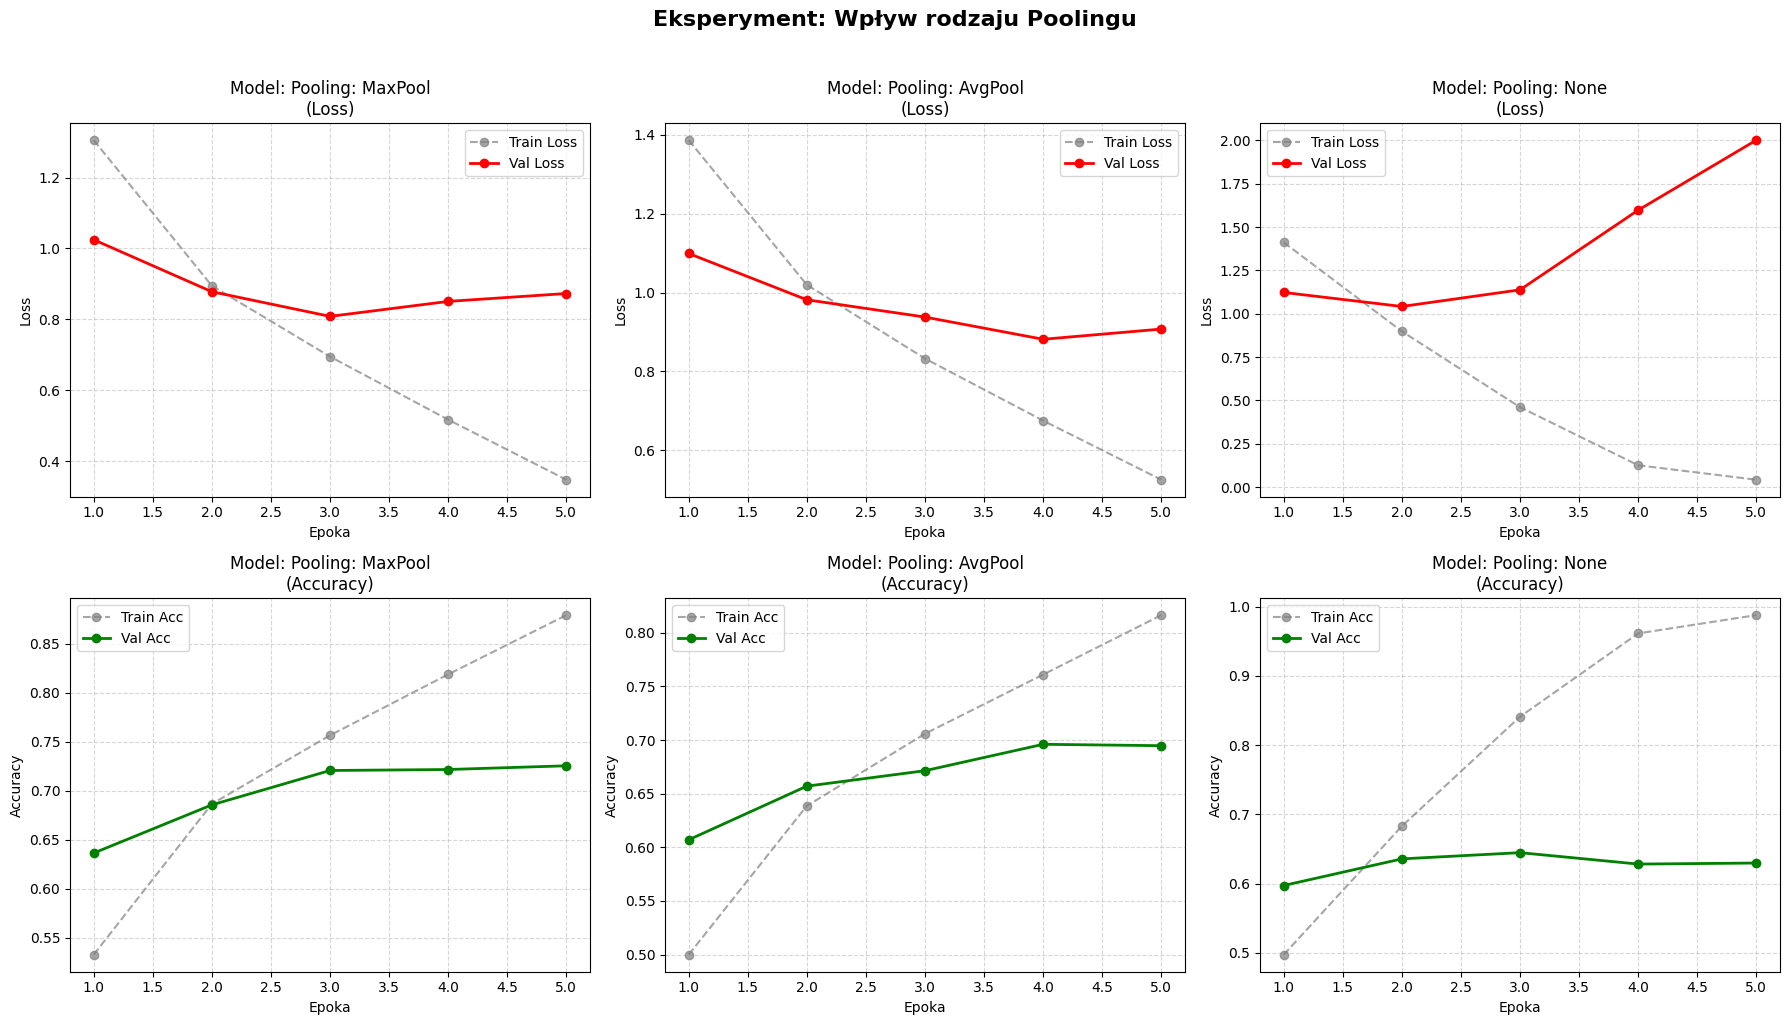

In [10]:
pooling_results = {}
pool_types = ['MaxPool', 'AvgPool', 'None']
num_epochs = 5

for pt in pool_types:
    print(f"\n{'='*40}")
    print(f"Rozpoczynam trening dla Poolingu = {pt}")
    print(f"{'='*40}")

    # Inicjalizujemy model. Zostawiamy kernel_size=3 jako nasz najlepszy wybór
    model = FlexCNN(kernel_size=3, pool_type=pt).to(device)

    # Ten sam optymalizator co poprzednio
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Trenujemy!
    history = train_model(model, train_loader, val_loader, criterion, optimizer, epochs=num_epochs)

    pooling_results[f'Pooling: {pt}'] = history

# Używamy naszej nowej, czytelnej funkcji do rysowania!
plot_experiment_results(pooling_results, "Wpływ rodzaju Poolingu")

**Wnioski z eksperymentu (Pooling):**
Wyniki jednoznacznie pokazują, dlaczego warstwy zmniejszające wymiarowość są kluczowe w architekturach CNN.
*   **Model bez poolingu (None):** W 5. epoce osiągnął prawie 100% dokładności na zbiorze treningowym i niemal zerowy błąd. Błąd walidacyjny jednak wystrzelił gwałtownie do góry. Przekazanie ogromnej, niezeskalowanej mapy cech z warstw konwolucyjnych do warstw FC doprowadziło do gigantycznej liczby parametrów w modelu i natychmiastowego zapamiętania zbioru treningowego (przeuczenie na poziomie wręcz podręcznikowym). Zatracił on zdolność do generalizacji.
*   **MaxPool vs AvgPool:** Najlepsze wyniki osiągnął model wykorzystujący `MaxPool`. Dokładność walidacyjna zatrzymała się na poziomie ok. 72%, podczas gdy dla uśredniania (AvgPool) była nieznacznie niższa. Wyciąganie najsilniejszych, wyróżniających cech z małych fragmentów obrazów (co robi MaxPool) okazało się skuteczniejszą strategią dla zbioru CIFAR-10 niż uśrednianie sygnału.

### Eksperyment 3: Wpływ współczynnika uczenia (Learning Rate)
W ostatniej serii sprawdzimy wpływ kluczowego hiperparametru optymalizatora – współczynnika uczenia. Decyduje on o tym, jak duże "kroki" robi sieć podczas aktualizacji wag.
Zbyt duży (np. 0.01) może sprawić, że sieć będzie przeskakiwać optimum (błąd będzie skakać), a zbyt mały (np. 0.0001) spowoduje, że sieć będzie uczyć się niezwykle powoli. Przetestujemy wartości: 0.01, 0.001 (nasz dotychczasowy) oraz 0.0001. Używamy naszej najlepszej architektury z poprzednich testów: `Kernel 3x3` oraz `MaxPool`.


Rozpoczynam trening dla Learning Rate = 0.01
Epoch 1/5 | Train Loss: 2.3261 Acc: 0.1001 | Val Loss: 2.3036 Acc: 0.0998
Epoch 2/5 | Train Loss: 2.3037 Acc: 0.0985 | Val Loss: 2.3030 Acc: 0.0967
Epoch 3/5 | Train Loss: 2.3036 Acc: 0.1013 | Val Loss: 2.3033 Acc: 0.0999
Epoch 4/5 | Train Loss: 2.3036 Acc: 0.0983 | Val Loss: 2.3041 Acc: 0.0963
Epoch 5/5 | Train Loss: 2.3036 Acc: 0.1007 | Val Loss: 2.3039 Acc: 0.1025

Rozpoczynam trening dla Learning Rate = 0.001
Epoch 1/5 | Train Loss: 1.2770 Acc: 0.5454 | Val Loss: 1.0072 Acc: 0.6424
Epoch 2/5 | Train Loss: 0.8892 Acc: 0.6875 | Val Loss: 0.8748 Acc: 0.6910
Epoch 3/5 | Train Loss: 0.6812 Acc: 0.7610 | Val Loss: 0.8315 Acc: 0.7088
Epoch 4/5 | Train Loss: 0.5013 Acc: 0.8239 | Val Loss: 0.8382 Acc: 0.7179
Epoch 5/5 | Train Loss: 0.3290 Acc: 0.8867 | Val Loss: 0.9495 Acc: 0.7234

Rozpoczynam trening dla Learning Rate = 0.0001
Epoch 1/5 | Train Loss: 1.5894 Acc: 0.4379 | Val Loss: 1.3463 Acc: 0.5181
Epoch 2/5 | Train Loss: 1.2698 Acc: 0.5526 | 

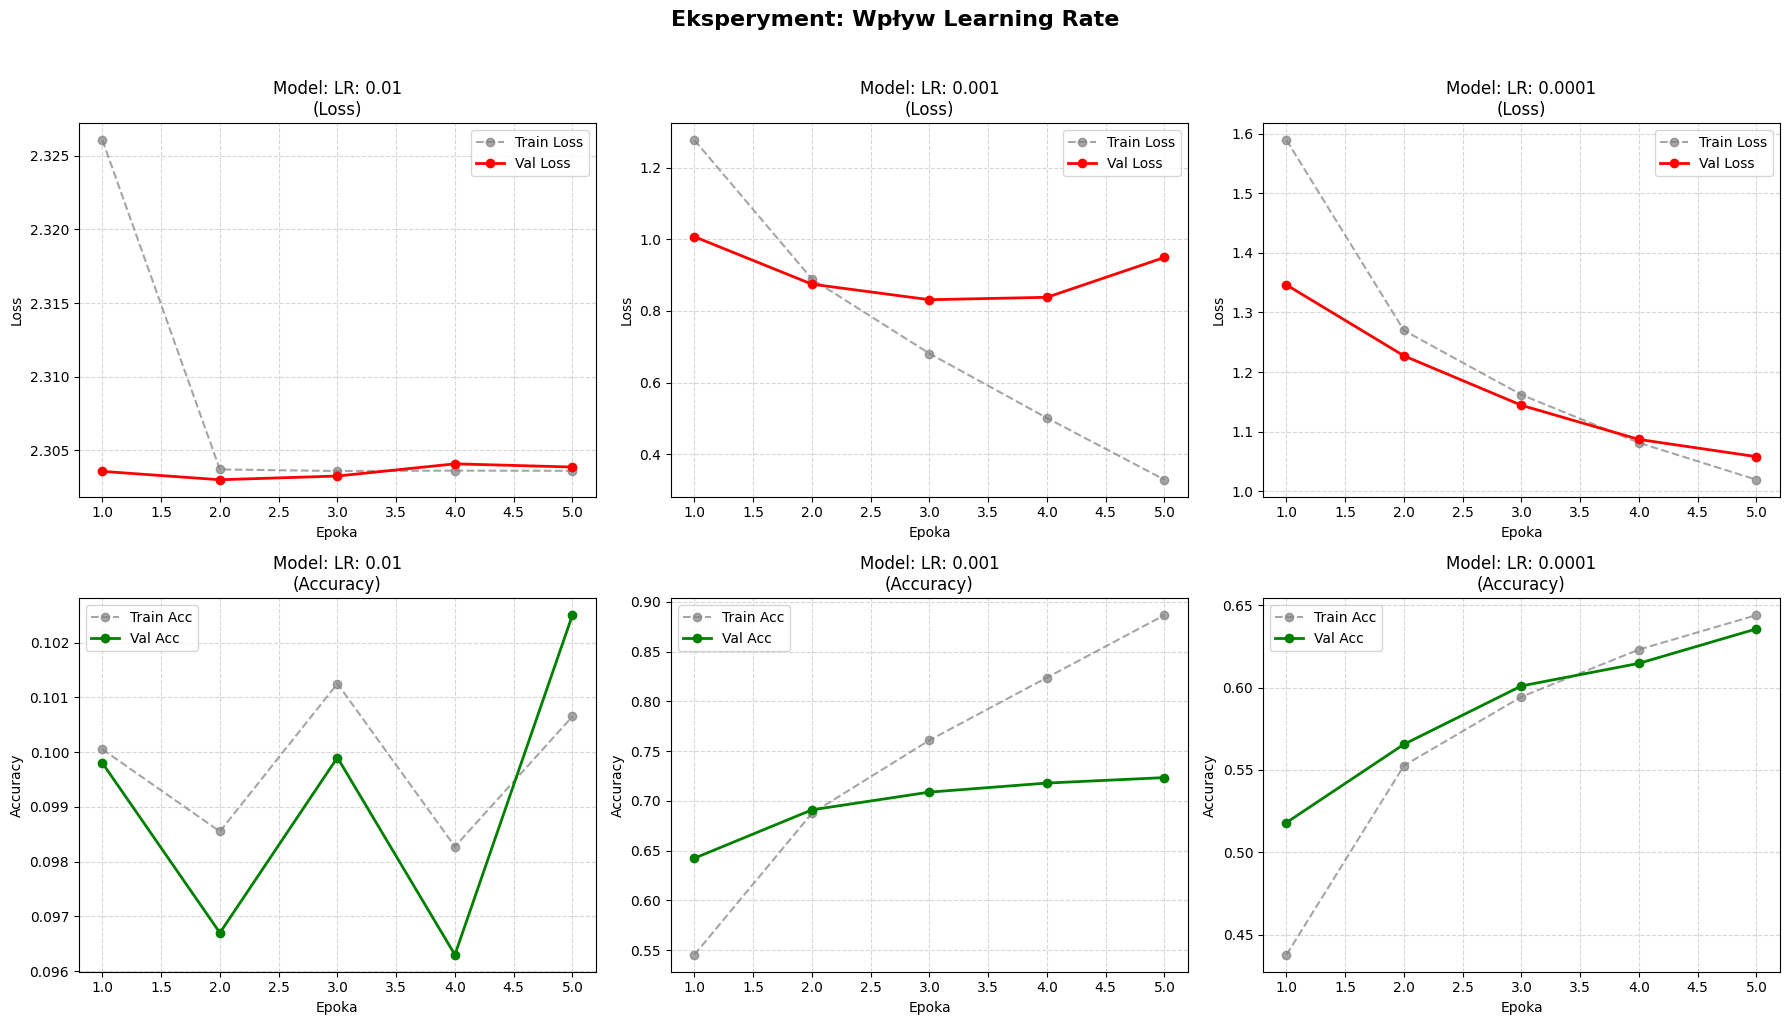

In [11]:
lr_results = {}
learning_rates = [0.01, 0.001, 0.0001]
num_epochs = 5

for lr in learning_rates:
    print(f"\n{'='*40}")
    print(f"Rozpoczynam trening dla Learning Rate = {lr}")
    print(f"{'='*40}")

    # Inicjalizujemy naszą najlepszą architekturę
    model = FlexCNN(kernel_size=3, pool_type='MaxPool').to(device)

    # Tym razem ZMIENIAMY podawany Learning Rate (lr)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = train_model(model, train_loader, val_loader, criterion, optimizer, epochs=num_epochs)

    lr_results[f'LR: {lr}'] = history

plot_experiment_results(lr_results, "Wpływ Learning Rate")

**Wnioski z eksperymentu (Learning Rate):**
Ten eksperyment świetnie obrazuje znaczenie odpowiednio dobranego rozmiaru "kroku" optymalizatora:
*   **LR = 0.01 (zbyt wysoki):** Wartość funkcji straty była niestabilna i pozostawała na bardzo wysokim poziomie, a dokładność wynosiła około 10%, co dla zbioru 10 klas oznacza zgadywanie losowe. Algorytm przy tak dużych krokach nie był w stanie znaleźć minimum funkcji straty.
*   **LR = 0.0001 (zbyt niski):** Uczenie postępowało poprawnie (błąd stale malał, a dokładność stabilnie rosła), jednak trwało zbyt wolno. Zatrzymaliśmy trening po 5 epokach, podczas gdy taki model potrzebowałby ich znacznie więcej, aby w pełni się nauczyć.
*   **LR = 0.001 (optymalny):** Okazał się najlepszym kompromisem dla tak krótkiego treningu, szybko ucząc się reprezentacji z obrazów i stabilizując "Validation Accuracy" na najwyższym poziomie (około 72%).

In [12]:
import pandas as pd
from IPython.display import display

def display_results_table(results_dict, experiment_name):
    """
    Funkcja pobiera słownik z historią uczenia i wyciąga dokładność z OSTATNIEJ epoki,
    aby wyświetlić ją w formie tabeli.
    """
    data = []
    for param_val, history in results_dict.items():
        # Pobieramy ostatni element z listy (czyli wynik po 5 epoce)
        final_train_acc = history['train_acc'][-1]
        final_val_acc = history['val_acc'][-1]

        data.append({
            'Wariant Hiperparametru': param_val,
            'Końcowe Train Acc': round(final_train_acc, 4),
            'Końcowe Val Acc': round(final_val_acc, 4)
        })

    df = pd.DataFrame(data)
    print(f"\n--- TABELA WYNIKÓW: {experiment_name} ---")
    display(df) # Wyświetla ładnie sformatowaną tabelę w Jupyterze


Rozpoczynam trening dla Batch Size = 16
Epoch 1/5 | Train Loss: 1.2410 Acc: 0.5560 | Val Loss: 1.0136 Acc: 0.6372
Epoch 2/5 | Train Loss: 0.8456 Acc: 0.7038 | Val Loss: 0.8429 Acc: 0.7028
Epoch 3/5 | Train Loss: 0.6271 Acc: 0.7805 | Val Loss: 0.8609 Acc: 0.7088
Epoch 4/5 | Train Loss: 0.4280 Acc: 0.8492 | Val Loss: 0.9349 Acc: 0.7173
Epoch 5/5 | Train Loss: 0.2660 Acc: 0.9057 | Val Loss: 1.0747 Acc: 0.7125

Rozpoczynam trening dla Batch Size = 64
Epoch 1/5 | Train Loss: 1.3492 Acc: 0.5141 | Val Loss: 1.0640 Acc: 0.6300
Epoch 2/5 | Train Loss: 0.9446 Acc: 0.6646 | Val Loss: 0.8986 Acc: 0.6847
Epoch 3/5 | Train Loss: 0.7655 Acc: 0.7301 | Val Loss: 0.8541 Acc: 0.7000
Epoch 4/5 | Train Loss: 0.6154 Acc: 0.7842 | Val Loss: 0.9146 Acc: 0.6878
Epoch 5/5 | Train Loss: 0.4646 Acc: 0.8392 | Val Loss: 0.9009 Acc: 0.7153

Rozpoczynam trening dla Batch Size = 128
Epoch 1/5 | Train Loss: 1.3789 Acc: 0.5082 | Val Loss: 1.0894 Acc: 0.6140
Epoch 2/5 | Train Loss: 0.9626 Acc: 0.6626 | Val Loss: 0.9176 

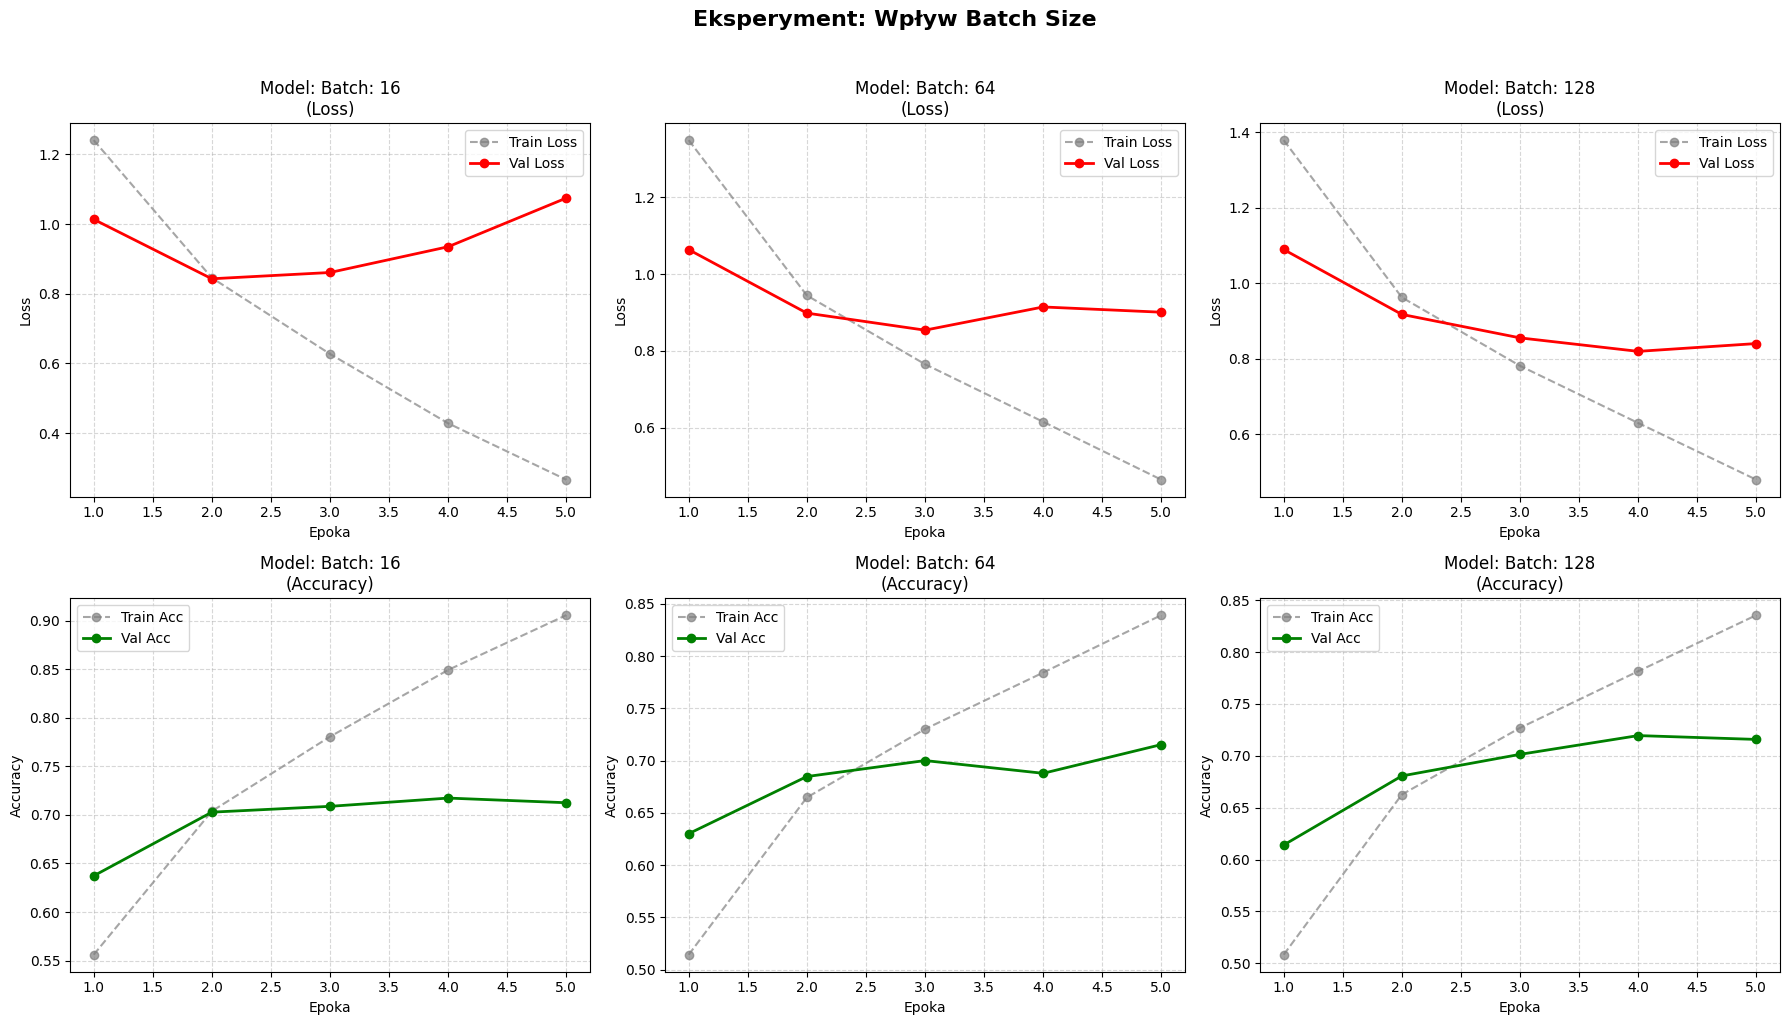


--- TABELA WYNIKÓW: Wpływ Batch Size ---


,Wariant Hiperparametru,Końcowe Train Acc,Końcowe Val Acc
0,Batch: 16,0.9057,0.7125
1,Batch: 64,0.8392,0.7153
2,Batch: 128,0.8356,0.7158


In [13]:
batch_results = {}
batch_sizes = [16, 64, 128] # Testujemy 3 różne rozmiary paczek
num_epochs = 5

for bs in batch_sizes:
    print(f"\n{'='*40}")
    print(f"Rozpoczynam trening dla Batch Size = {bs}")
    print(f"{'='*40}")

    # Tworzymy nowe loadery z aktualnie testowanym Batch Size
    train_loader_bs = DataLoader(train_dataset, batch_size=bs, shuffle=True)
    val_loader_bs = DataLoader(val_dataset, batch_size=bs, shuffle=False)

    # Używamy najlepszej architektury
    model = FlexCNN(kernel_size=3, pool_type='MaxPool').to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    #przekazujem tu nowe loadery (train_loader_bs, val_loader_bs)
    history = train_model(model, train_loader_bs, val_loader_bs, criterion, optimizer, epochs=num_epochs)

    batch_results[f'Batch: {bs}'] = history

# Rysujemy wykres
plot_experiment_results(batch_results, "Wpływ Batch Size")

# TWORZYMY WYMAGANĄ TABELĘ!
display_results_table(batch_results, "Wpływ Batch Size")

**Wnioski z eksperymentu (Batch Size):**
Eksperyment pokazał, jak wielkość jednorazowej "paczki" danych dostarczanych do sieci wpływa na szybkość i jakość uczenia.
Najmniejszy *Batch Size* (16) cechował się bardzo szybkim procesem trenowania, ale wykazał najszybszą i najbardziej agresywną tendencję do przeuczenia (błąd walidacyjny zaczął rosnąć niemal pionowo po drugiej epoce). Wynika to z faktu, że częste aktualizacje wag dla małych próbek wprowadzają dużo niestabilności ("szumu") do gradientu.
Z kolei większe rozmiary paczek (64 i 128) sprawiły, że proces uczenia był bardziej wygładzony i stabilny. Optymalnym balansem dla tego środowiska obliczeniowego oraz naszej architektury okazała się domyślna wartość 64, dająca stabilny wykres błędu walidacyjnego przy zachowaniu przyzwoitej skuteczności uczenia.

Trenowanie ostatecznego modelu...
Epoch 1/5 | Train Loss: 1.3420 Acc: 0.5193 | Val Loss: 1.0687 Acc: 0.6185
Epoch 2/5 | Train Loss: 0.9334 Acc: 0.6706 | Val Loss: 0.9138 Acc: 0.6807
Epoch 3/5 | Train Loss: 0.7317 Acc: 0.7440 | Val Loss: 0.8743 Acc: 0.6942
Epoch 4/5 | Train Loss: 0.5644 Acc: 0.8039 | Val Loss: 0.8385 Acc: 0.7134
Epoch 5/5 | Train Loss: 0.4022 Acc: 0.8615 | Val Loss: 0.8961 Acc: 0.7136

EWALUACJA NA ZBIORZE TESTOWYM

Raport Klasyfikacji (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

       plane       0.73      0.80      0.76      1000
         car       0.76      0.87      0.81      1000
        bird       0.67      0.54      0.60      1000
         cat       0.57      0.44      0.50      1000
        deer       0.67      0.63      0.65      1000
         dog       0.62      0.59      0.61      1000
        frog       0.81      0.77      0.79      1000
       horse       0.64      0.85      0.73      1000
        ship       0.81   

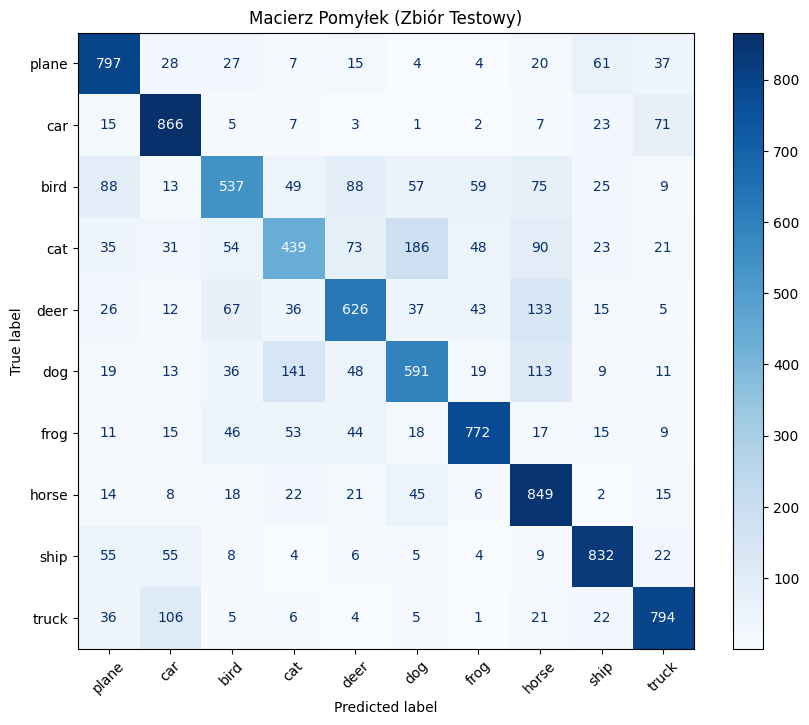

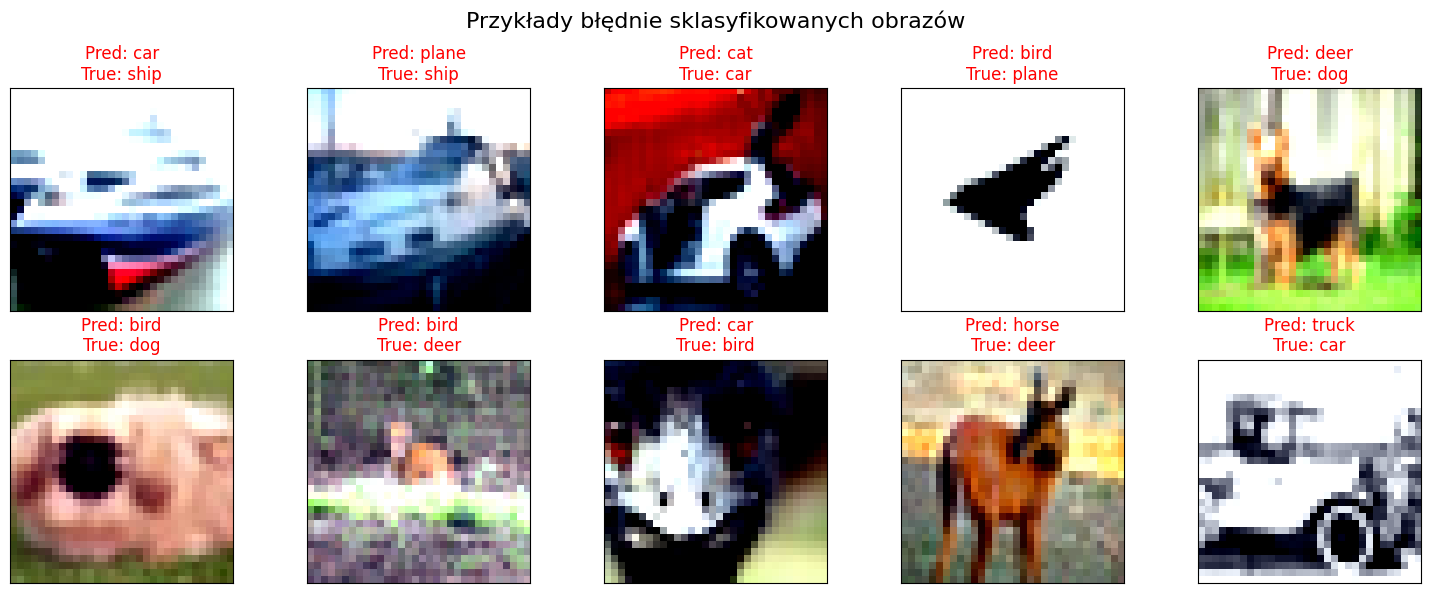

In [14]:
print("Trenowanie ostatecznego modelu...")
# Inicjalizacja najlepszego modelu
best_model = FlexCNN(kernel_size=3, pool_type='MaxPool').to(device)
best_optimizer = optim.Adam(best_model.parameters(), lr=0.001)

# Krótki trening najlepszego modelu (używamy standardowego batch_size=64)
_ = train_model(best_model, train_loader, val_loader, criterion, best_optimizer, epochs=5)

print("\n" + "="*50)
print("EWALUACJA NA ZBIORZE TESTOWYM")
print("="*50)

best_model.eval()
all_preds = []
all_labels = []
misclassified_images = []
misclassified_labels = []
misclassified_preds = []

# Wyłączenie obliczania gradientów (oszczędza pamięć i przyspiesza testowanie)
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = best_model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        # Zbieranie błędnie sklasyfikowanych obrazów do późniejszej wizualizacji
        mask = preds != labels
        for i in range(len(mask)):
            if mask[i] and len(misclassified_images) < 10:
                misclassified_images.append(images[i].cpu())
                misclassified_labels.append(labels[i].cpu().item())
                misclassified_preds.append(preds[i].cpu().item())

# 1. Raport klasyfikacji
print("\nRaport Klasyfikacji (Precision, Recall, F1-Score):")
print(classification_report(all_labels, all_preds, target_names=classes))

# 2. Macierz pomyłek (Confusion Matrix)
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap='Blues', values_format='d', ax=plt.gca())
plt.title('Macierz Pomyłek (Zbiór Testowy)')
plt.xticks(rotation=45)
plt.show()

# 3. Wizualizacja błędów
fig = plt.figure(figsize=(15, 6))
fig.suptitle('Przykłady błędnie sklasyfikowanych obrazów', fontsize=16)

for idx in range(len(misclassified_images)):
    ax = fig.add_subplot(2, 5, idx+1, xticks=[], yticks=[])

    # Denormalizacja obrazu, aby kolory wyglądały naturalnie
    img = misclassified_images[idx]
    img = img / 2 + 0.5
    img = np.clip(img.numpy(), 0, 1)
    plt.imshow(np.transpose(img, (1, 2, 0)))

    true_label = classes[misclassified_labels[idx]]
    pred_label = classes[misclassified_preds[idx]]
    ax.set_title(f"Pred: {pred_label}\nTrue: {true_label}", color="red")

plt.tight_layout()
plt.show()

## 7. Podsumowanie ogólne

Przeprowadzona seria eksperymentów pozwoliła nam zidentyfikować optymalny zestaw podstawowych hiperparametrów dla prostej sieci konwolucyjnej pracującej na zbiorze CIFAR-10. Najlepiej sprawdziła się konfiguracja:
*   Rozmiar filtra (Kernel Size): **3x3**
*   Typ Poolingu: **MaxPool**
*   Learning Rate: **0.001**
*   Batch Size: **64**

Biorąc jednak pod uwagę widoczne w niemal wszystkich eksperymentach (przy poprawnym Learning Rate) zjawisko **przeuczenia (overfitting)**, widać wyraźnie, że zaprezentowana sieć `FlexCNN` posiadała zbyt dużą pojemność w stosunku do dostarczonych danych bez użycia technik zabezpieczających. Błąd na zbiorze walidacyjnym po 3-4 epoce systematycznie wzrastał, podczas gdy model zaczął zapamiętywać obrazy treningowe.


In [16]:
!pip freeze > requirements.txt
print("Plik requirements.txt został wygenerowany!")

Plik requirements.txt został wygenerowany!
